# Praktikum 2: Implementasi dan Eksplorasi K-Means

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

## 1. Pengantar k-Means

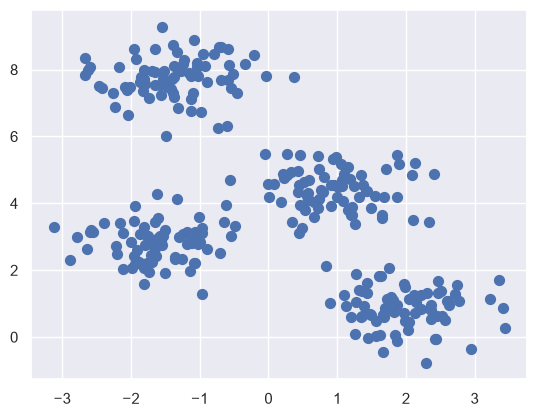

In [2]:
# Generate dataset sintetis dengan 4 cluster
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [3]:
# Melatih model KMeans dengan 4 cluster
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

c:\Users\M ALDYTH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


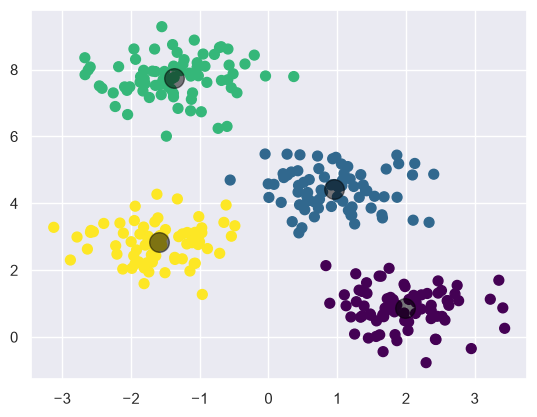

In [4]:
# Visualisasi hasil pengelompokan dan titik pusat cluster (centroid)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

## 2. Algoritma Expectation-Maximization (Manual KMeans)

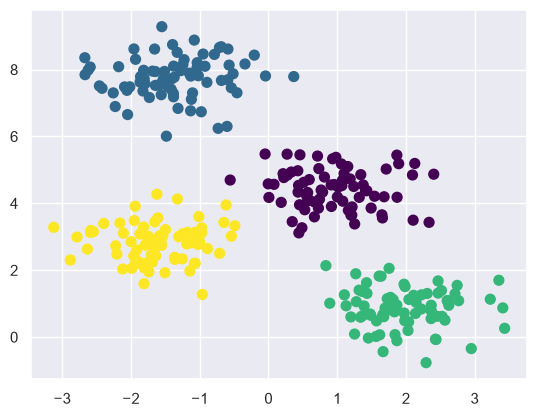

In [5]:
# Fungsi manual KMeans menggunakan algoritma Expectation-Maximization
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]
    
    while True:
        # 2a. assign label berdasarkan centroid terdekat
        labels = pairwise_distances_argmin(X, centers)
        
        # 2b. hitung centroid baru berdasarkan rata-rata titik
        new_centers = np.array([X[labels == i].mean(0) for i in range(n_clusters)])
        
        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers
    
    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

### Perubahan Random Seed (Inisialisasi Awal)

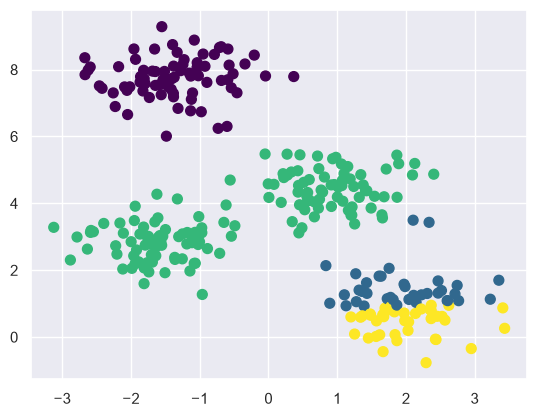

In [6]:
# Menguji pengaruh perubahan random seed terhadap hasil clustering
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

### Eksperimen Jumlah Klaster (k=6)

c:\Users\M ALDYTH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


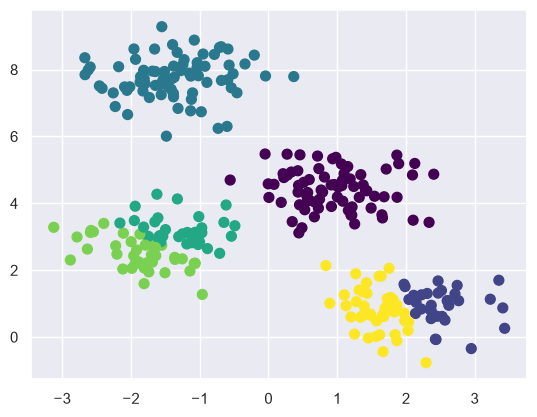

In [7]:
# Menjalankan KMeans dengan k yang berlebihan (over-clustering)
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

## 3. Batas Klaster Non-Linier (Dataset Moon)

In [8]:
# Generate dataset berbentuk bulan sabit (make_moons)
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

c:\Users\M ALDYTH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


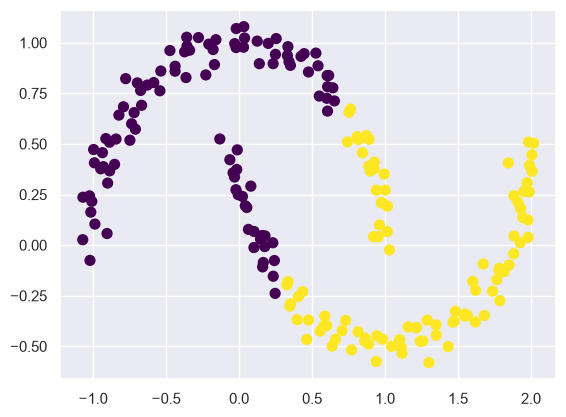

In [9]:
# Menguji KMeans standar pada data non-linier (hasil tidak optimal)
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

c:\Users\M ALDYTH\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\M ALDYTH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


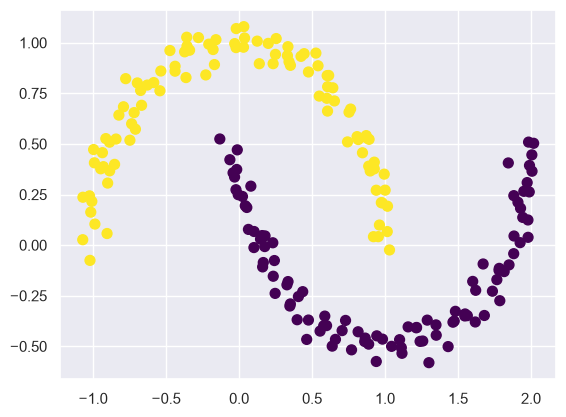

In [10]:
# Menggunakan SpectralClustering untuk menangani pola data non-linier
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

## 4. Contoh Kasus 1: Pengenalan Karakter Angka (Digits)

In [11]:
# Load dataset Digits
from sklearn.datasets import load_digits
digits = load_digits()
print(digits.data.shape)

(1797, 64)


In [12]:
# Terapkan K-Means untuk 10 kelas (0-9)
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
print(kmeans.cluster_centers_.shape)

(10, 64)


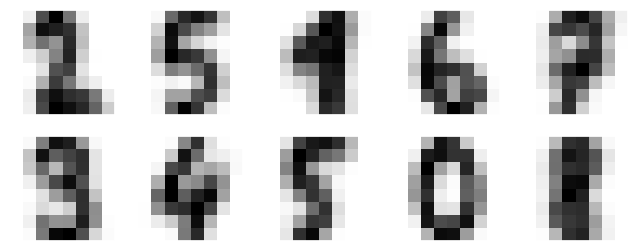

In [13]:
# Visualisasi titik pusat cluster (centroid) sebagai gambar angka
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

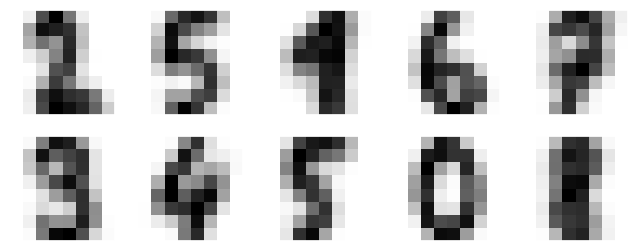

In [14]:
# Visualisasi titik pusat cluster (centroid) sebagai gambar angka
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [15]:
# Pencocokan label cluster dengan kelas angka sebenarnya
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [16]:
# Evaluasi Akurasi awal K-Means
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

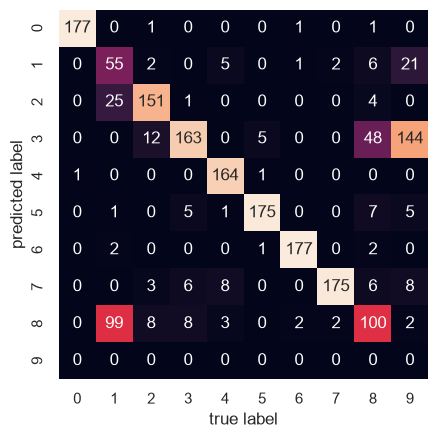

In [17]:
# Matriks Konfusi (Confusion Matrix)
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [18]:
# Peningkatan Akurasi Menggunakan t-SNE (Reduksi Dimensi)
from sklearn.manifold import TSNE

# Reduksi dimensi fitur dari 64 menjadi 2 dimensi dengan t-SNE
tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# Hitung cluster kembali dengan K-Means pada data hasil t-SNE
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# Permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# Hitung akurasi setelah t-SNE
accuracy_score(digits.target, labels)

0.9410127991096272

## 5. Studi Kasus 2: Kompresi Citra (Color Quantization)

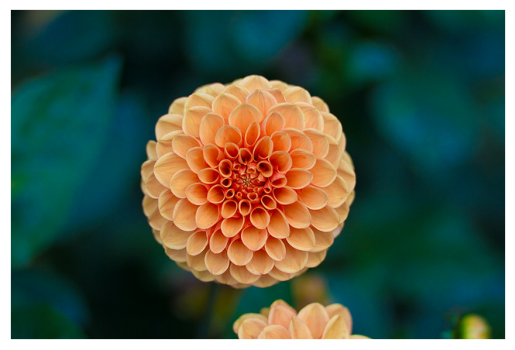

In [19]:
# Load sampel citra bunga
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [20]:
# Cek dimensi citra awal
print(flower.shape)

(427, 640, 3)


In [21]:
# Normalisasi dan reshape data gambar
data = flower / 255.0
data = data.reshape(427 * 640, 3)
print(data.shape)

(273280, 3)


In [22]:
# Fungsi bantuan untuk meragakan sebaran warna piksel
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data
    
    # Pilih subset acak
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

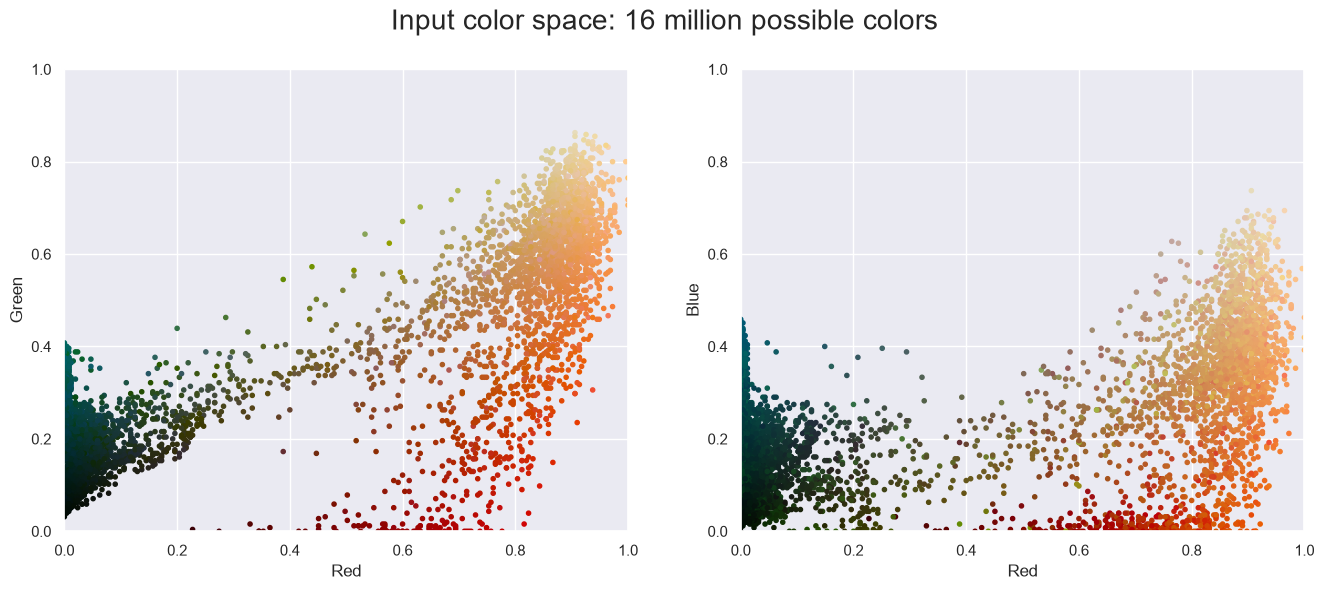

In [23]:
# Visualisasi sebaran warna awal
plot_pixels(data, title='Input color space: 16 million possible colors')

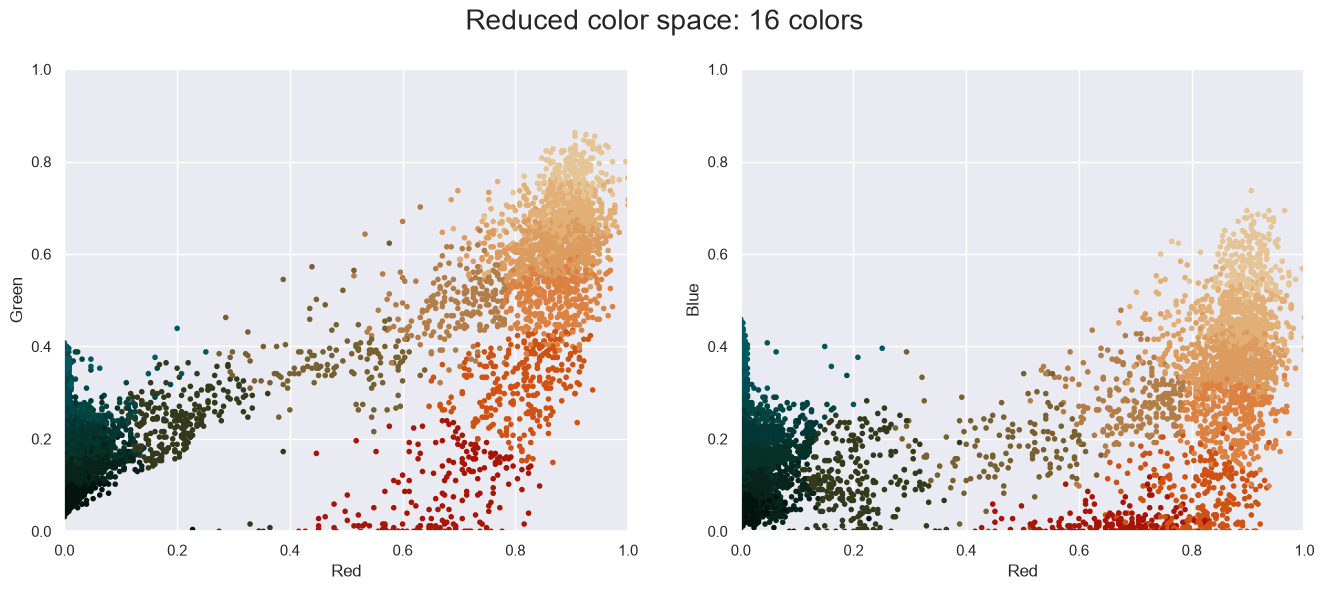

In [24]:
# Kompresi warna menjadi 16 warna utama menggunakan MiniBatchKMeans
import warnings; warnings.simplefilter('ignore')

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors, title="Reduced color space: 16 colors")

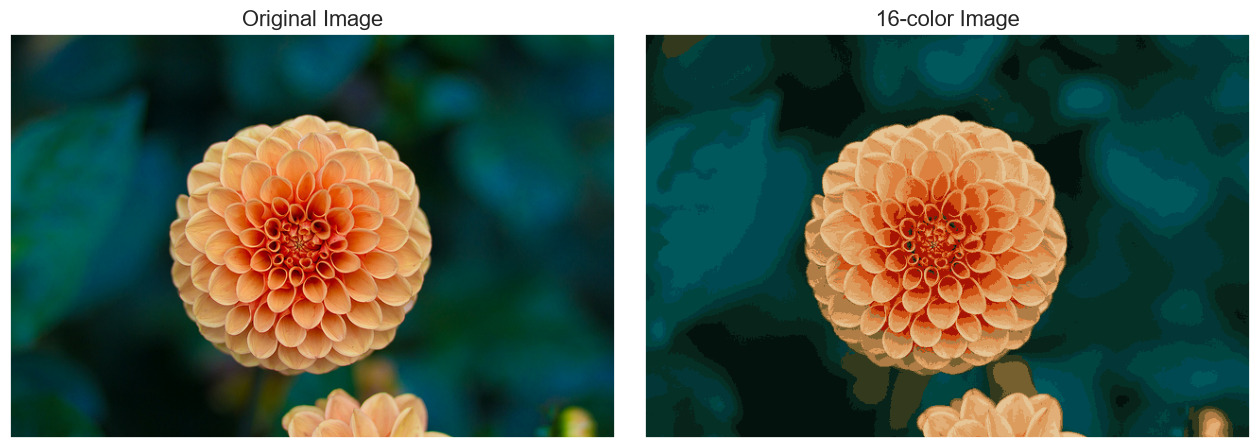

In [25]:
# Visualisasi Perbandingan Citra Asli vs Hasil Kompresi
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                        subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);